1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. Load the Dataset

In [3]:
df = pd.read_csv("/content/sales_data_with_discounts.csv")

In [4]:
df

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770
...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,15-04-2021,Thursday,L06,C,2,Lifestyle,Jeera,M-Casuals,1300,2600,15.475687,402.367873,2197.632127
446,15-04-2021,Thursday,L07,C,6,Lifestyle,Viva,W-Western,2600,15600,17.057027,2660.896242,12939.103758
447,15-04-2021,Thursday,L08,C,2,Lifestyle,Viva,W-Lounge,1600,3200,18.965550,606.897606,2593.102394
448,15-04-2021,Thursday,L09,C,3,Lifestyle,Jeera,M-Formals,1900,5700,16.793014,957.201826,4742.798174


In [5]:
print(df.head())

         Date       Day  SKU City  Volume       BU  Brand       Model  \
0  01-04-2021  Thursday  M01    C      15  Mobiles  RealU       RU-10   
1  01-04-2021  Thursday  M02    C      10  Mobiles  RealU   RU-9 Plus   
2  01-04-2021  Thursday  M03    C       7  Mobiles   YouM       YM-99   
3  01-04-2021  Thursday  M04    C       6  Mobiles   YouM  YM-99 Plus   
4  01-04-2021  Thursday  M05    C       3  Mobiles   YouM      YM-98    

   Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0      12100             181500          11.654820     21153.498820   
1      10100             101000          11.560498     11676.102961   
2      16100             112700           9.456886     10657.910157   
3      20100             120600           6.935385      8364.074702   
4       8100              24300          17.995663      4372.946230   

   Net Sales Value  
0    160346.501180  
1     89323.897039  
2    102042.089843  
3    112235.925298  
4     19927.053770  


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB
None


3. Descriptive Analytics for Numerical Columns

In [7]:
numerical_cols = df.select_dtypes(include=np.number).columns
print(numerical_cols)

Index(['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)',
       'Discount Amount', 'Net Sales Value'],
      dtype='object')


Calculate Mean, Median, Mode, and Standard Deviation

In [8]:
for col in numerical_cols:
    print(f"\n--- {col} ---")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    # Mode can return multiple values, so handle it as a series
    mode_values = df[col].mode()
    if not mode_values.empty:
        print(f"Mode: {mode_values.tolist()}")
    else:
        print("Mode: No unique mode")
    print(f"Standard Deviation: {df[col].std():.2f}")


--- Volume ---
Mean: 5.07
Median: 4.00
Mode: [3]
Standard Deviation: 4.23

--- Avg Price ---
Mean: 10453.43
Median: 1450.00
Mode: [400, 450, 500, 1300, 8100]
Standard Deviation: 18079.90

--- Total Sales Value ---
Mean: 33812.84
Median: 5700.00
Mode: [24300]
Standard Deviation: 50535.07

--- Discount Rate (%) ---
Mean: 15.16
Median: 16.58
Mode: [5.007822189204133, 5.055218412429214, 5.059801277154096, 5.072124185625713, 5.084108426, 5.252112549273296, 5.4118021861669225, 5.420506661087877, 5.425910532590122, 5.466379335661308, 5.485156670073213, 5.511042321019265, 5.553719335858815, 5.794802079132935, 5.870670938165718, 5.935084193732397, 6.008199566158192, 6.066191918625036, 6.095201440402829, 6.106930704565366, 6.170397894995827, 6.214888201701022, 6.268913808500697, 6.326891692775114, 6.415230294327099, 6.439919959844064, 6.473304705016388, 6.508719077620175, 6.642595335085532, 6.710453536396899, 6.819110662867928, 6.849975641919071, 6.8582545692088726, 6.935385325, 7.1787258992413

4. Data Visualization

A. Histograms

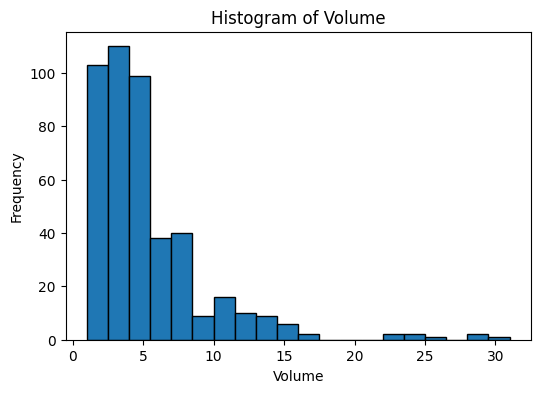

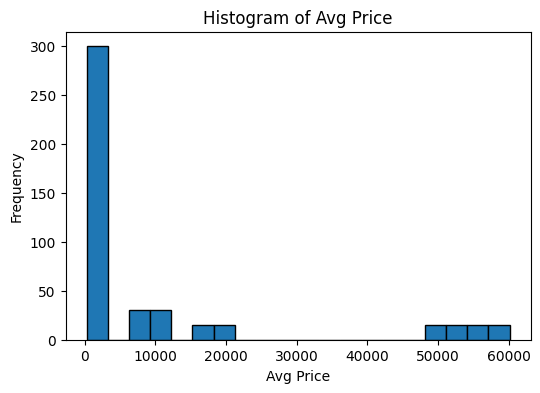

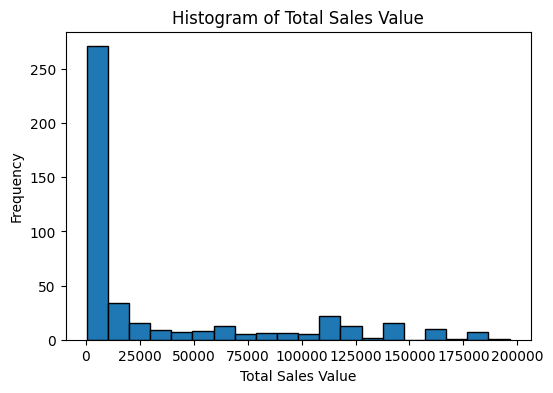

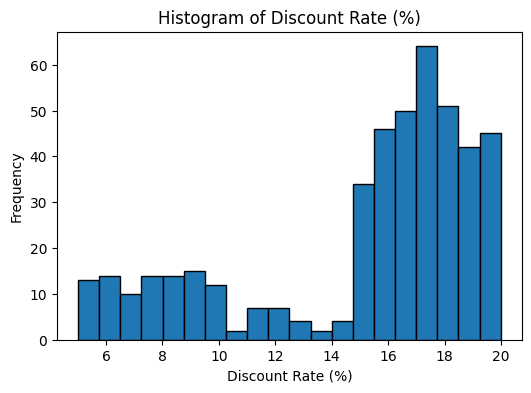

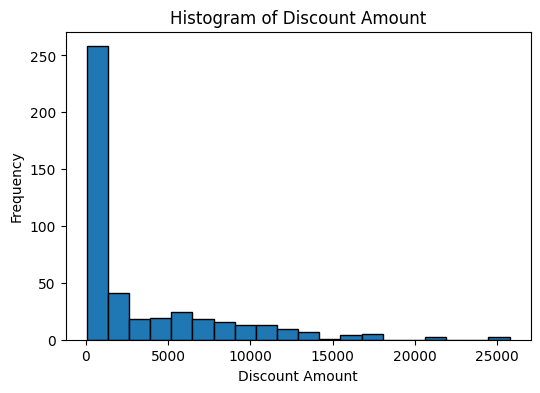

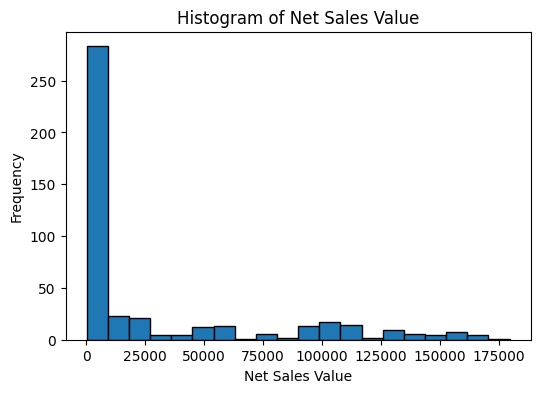

In [9]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

5. Bar Chart Analysis for Categorical Columns

In [10]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')


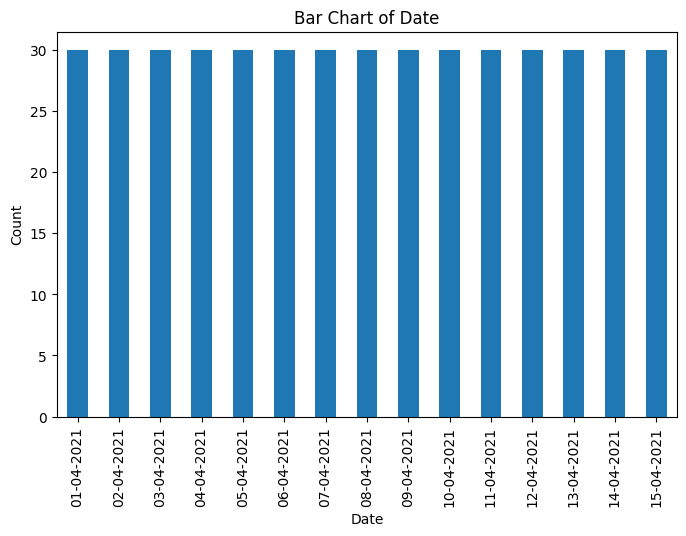

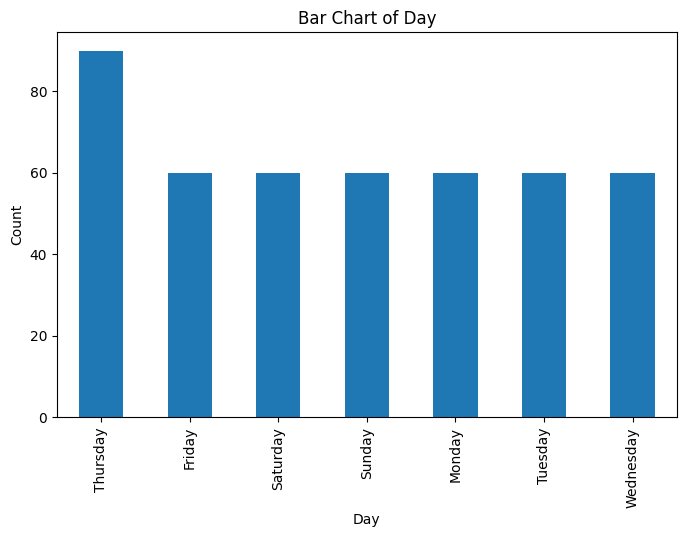

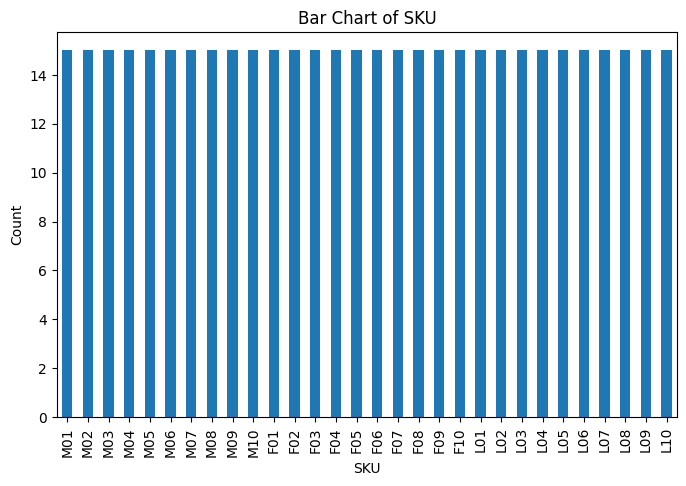

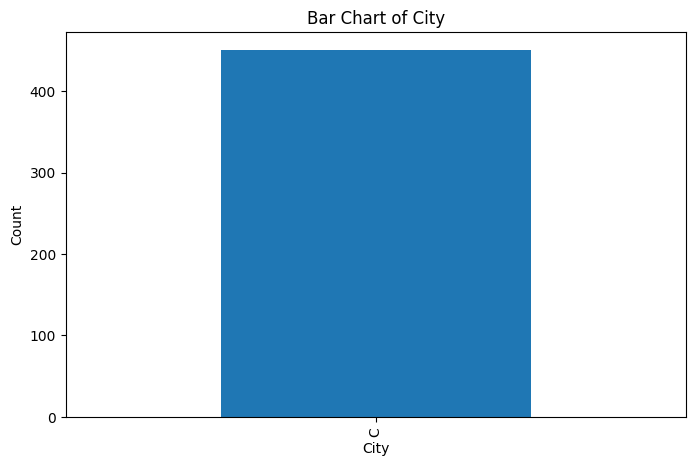

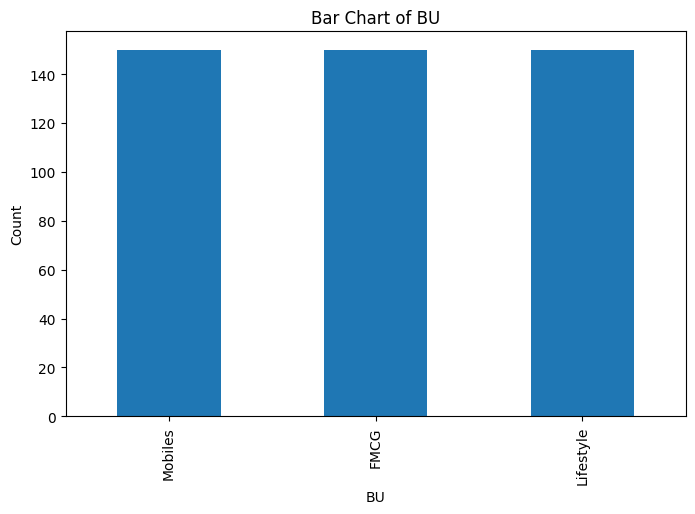

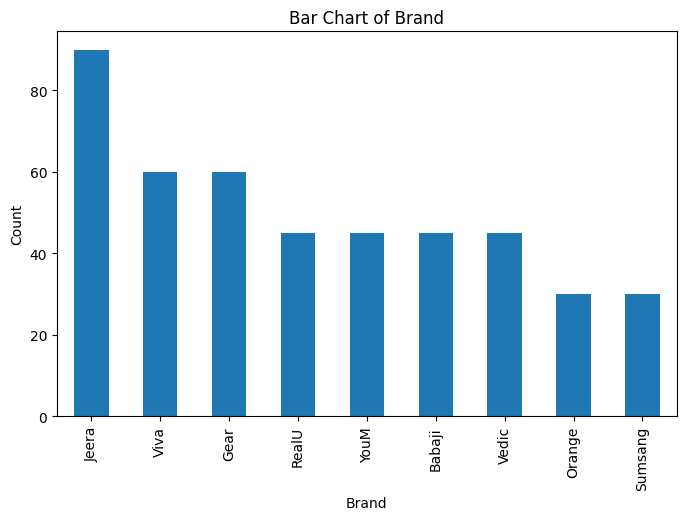

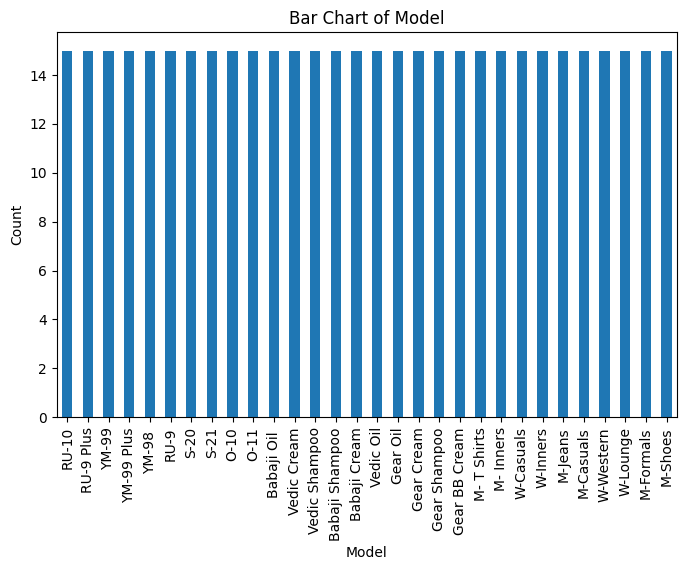

In [11]:
for col in categorical_cols:
    plt.figure(figsize=(8,5))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Bar Chart of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

6. Data Preprocessing

Check Missing Values

In [12]:
print(df.isnull().sum())

Date                 0
Day                  0
SKU                  0
City                 0
Volume               0
BU                   0
Brand                0
Model                0
Avg Price            0
Total Sales Value    0
Discount Rate (%)    0
Discount Amount      0
Net Sales Value      0
dtype: int64


Fill Missing Numerical Values

In [13]:
for col in numerical_cols:
    df[col].fillna(df[col].mean(), inplace=True)

/tmp/ipykernel_15218/1059054142.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


Fill Missing Categorical Values

In [14]:
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_15218/1077209983.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


Check Duplicate Rows

In [15]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [16]:
df.drop_duplicates(inplace=True)